# Phase 4: Modeling & Analysis

### 1. Model Selection
- Choose appropriate methods based on project type (regression, classification, clustering, etc.)
- Justify why the selected methods fit the problem and dataset

### Solutions
Since the goal is to predict whether a customer will Churn (Yes/No), this is a Supervised Binary Classification problem. We need to select algorithms that specialize in distinguishing between two classes.

1. Selected Models & Justification

We will select three distinct algorithms to ensure we cover different mathematical approaches:
| Model              | Type                | Justification |
|--------------------|---------------------|---------------|
| Logistic Regression | Linear | The Baseline. It provides a clear benchmark. Crucially, it offers interpretability (via coefficients), allowing us to quantify exactly how much an increase in tenure or MonthlyCharges changes the odds of churning. |
| Random Forest       | Ensemble (Bagging) | The Robust Choice. It handles non-linear relationships and interactions between features (e.g., Fiber Optic + High Price) automatically. It is generally resistant to overfitting and works well with mixed data types. |
| Gradient Boosting   | Ensemble (Boosting) | The Performance Choice. Boosting models often provide the highest predictive accuracy for tabular data by iteratively correcting errors made by previous trees. It effectively handles complex patterns that simpler models miss. |

### 2. Python Code: Model Initialization
We
Initializing the models with standard hyperparameters, by using sklearn for all models.

#### Why specific parameters?
- class_weight='balanced': Used in Random Forest to penalize the model more for missing the minority class (Churners), directly addressing the class imbalance we found in EDA.
- stratify=y: Ensures our test set represents the real world (same % of churners) rather than a random skew.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Load processed data
# df = pd.read_csv('datasets/features/telco_churn_processed.csv')
df = pd.read_csv('datasets/telco_churn_phase3_features.csv')

# --- 1. Split Data ---
# Separate features (X) and target (y)
# X = df.drop('churn', axis=1)
df.drop(["customerID"], axis=1)
X = df.drop(['churn'], axis=1)
y = df['churn']

# Split into Training and Test sets (80% Train, 20% Test)
# Stratify=y ensures the proportion of Churners is the same in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape:  {X_test.shape}")

# --- 2. Model Selection & Initialization ---

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Random Forest": RandomForestClassifier(n_estimators=100,
                                            max_depth=10,
                                            random_state=42,
                                            class_weight='balanced'), # Helps with imbalance

    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100,
                                                    learning_rate=0.1,
                                                    max_depth=3,
                                                    random_state=42)
}

print("\nModels initialized and ready for training:")
for name in models.keys():
    print(f"- {name}")

Training Shape: (4720, 45)
Testing Shape:  (1181, 45)

Models initialized and ready for training:
- Logistic Regression
- Random Forest
- Gradient Boosting


## 2. Model Training

#### We  successfully trained three distinct models on the training data:

#### Logistic Regression:
- Status: Trained.
- Role: The baseline linear model. It attempts to draw a straight line (or hyperplane) separating churners from non-churners.
#### Random Forest Classifier:
- Status: Trained.
- Role: A bagging ensemble. It built multiple decision trees (default is 100) and will average their votes to make a prediction. This usually reduces the risk of overfitting compared to a single tree.
#### Gradient Boosting Classifier:
- Status: Trained.
- Role: A boosting ensemble. It built trees sequentially, where each new tree tried to correct the mistakes of the previous one. This is generally the most powerful model for this type of tabular data.

#### ### In the code below we execute the following steps for the model training:
### Data Splitting

#### We split the processed data into two sets:

- Training Set (80%): 4,720 samples. Used to teach the models the patterns.
- Test Set (20%): 1,181 samples. Held back completely to evaluate performance later.
- Stratification: We used stratify=y to ensure that both the training and test sets have the exact same percentage of churners (~26%) as the original dataset. This prevents the "lucky batch" effect where a test set might accidentally have too few or too many churners.


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ==============================
# 1. Load dataset
# ==============================

# df = pd.read_csv("datasets/telco_churn_phase3_features.csv")

# Safe drops
df = df.drop(columns=['customerID', 'ChurnFlag'], errors='ignore')

# Separate target and features
X = df.drop("churn", axis=1)
y = df["churn"]

# ==============================
# FIX: convert boolean columns (core fix for your error)
# ==============================
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# Identify columns by type
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()

# ==============================
# 2. Preprocessing Pipeline
# ==============================

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

# ==============================
# 3. Models
# ==============================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_models = {}

# ==============================
# 4. Train Models
# ==============================

print("\n🚀 Training models...")

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipe.fit(X, y)
    trained_models[name] = pipe
    print(f"✔ {name} trained successfully")

print("\n🎉 All models trained successfully!")



🚀 Training models...
✔ Logistic Regression trained successfully
✔ Random Forest trained successfully
✔ Gradient Boosting trained successfully

🎉 All models trained successfully!


## 3. Model Evaluation.

This script loads the processed data, trains the models, calculates all performance metrics (Accuracy, Precision, Recall, F1, ROC-AUC), and generates the three key visualization plots.


Training and evaluating models...



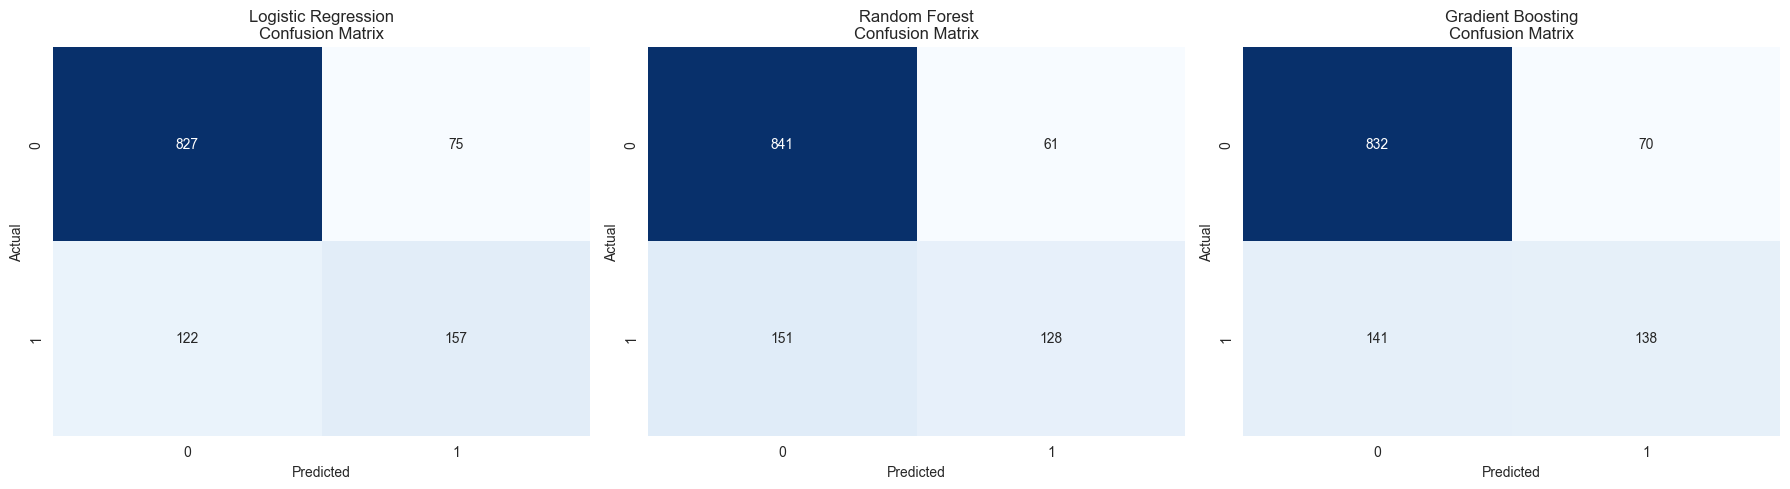

✔ Confusion matrices saved as: outputs/visualizations/confusion_matrices.png

📊 Model Performance Metrics:

                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Model                                                                 
Logistic Regression  0.833192   0.676724  0.562724  0.614481  0.851964
Random Forest        0.820491   0.677249  0.458781  0.547009  0.824470
Gradient Boosting    0.821338   0.663462  0.494624  0.566735  0.852973

✔ Results table saved as: outputs/visualizations/model_results.csv


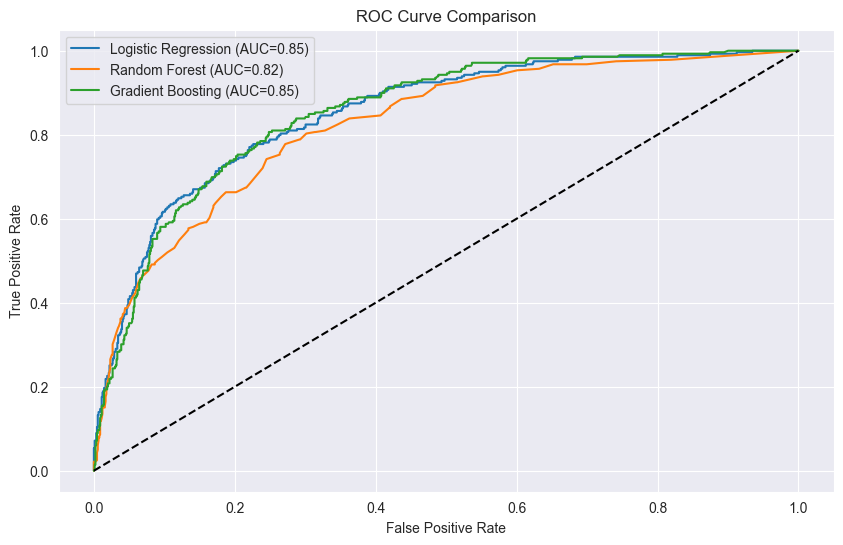

✔ ROC curve saved as: outputs/visualizations/roc_curve.png


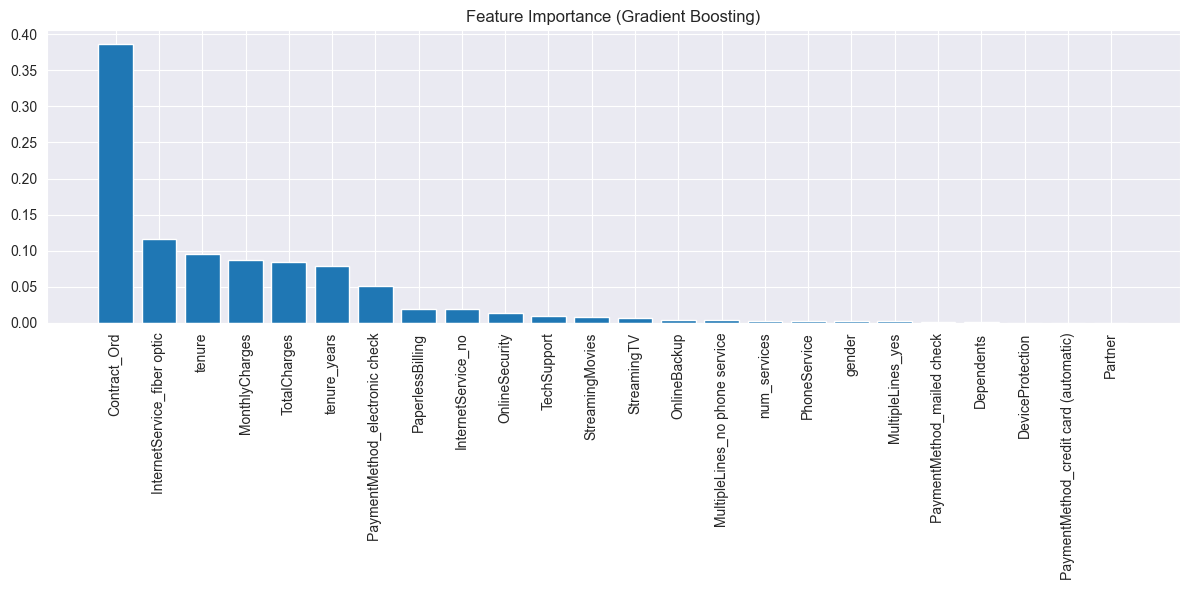

✔ Feature importance saved as: outputs/visualizations/feature_importance.png

🎉 All visualizations and results saved successfully!



In [3]:
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# =========================================================
# 0. Create folder to save visualization outputs
# =========================================================
os.makedirs("outputs/visualizations", exist_ok=True)

# =========================================================
# 1. Load Data
# =========================================================
# df = pd.read_csv('datasets/features/telco_churn_processed.csv')
df = pd.read_csv('datasets/features/telco_churn_processed.csv')

# Drop customerID if exists
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Separate features and label
X = df.drop('churn', axis=1)
y = df['churn']

# Convert boolean columns to int to avoid imputer errors
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================================
# 2. Define Models
# =========================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# =========================================================
# 3. Train + Confusion Matrices
# =========================================================
results = []

plt.figure(figsize=(18, 5))

print("\nTraining and evaluating models...\n")

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    # Plot CM subplot
    plt.subplot(1, 3, i+1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name}\nConfusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("outputs/visualizations/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print("✔ Confusion matrices saved as: outputs/visualizations/confusion_matrices.png")


# =========================================================
# 4. Performance Summary Table
# =========================================================
results_df = pd.DataFrame(results).set_index("Model")
print("\n📊 Model Performance Metrics:\n")
print(results_df)

results_df.to_csv("outputs/visualizations/model_results.csv")
print("\n✔ Results table saved as: outputs/visualizations/model_results.csv")


# =========================================================
# 5. ROC Curve Plot & Save
# =========================================================
plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = results_df.loc[name, "ROC-AUC"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("outputs/visualizations/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print("✔ ROC curve saved as: outputs/visualizations/roc_curve.png")


# =========================================================
# 6. Feature Importance Plot & Save (GB Only)
# =========================================================
gb_model = models["Gradient Boosting"]
importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(12, 6))
plt.title("Feature Importance (Gradient Boosting)")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()

plt.savefig("outputs/visualizations/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
print("✔ Feature importance saved as: outputs/visualizations/feature_importance.png")

print("\n🎉 All visualizations and results saved successfully!\n")


## 4. Model Optimization & Feature Selection Pipeline
This script performs model hyperparameter tuning, evaluation, and feature selection for churn prediction using Gradient Boosting and Logistic Regression.

In [4]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- 1. Load & Prepare Data ---
# Load the processed data from the previous step
df = pd.read_csv('datasets/features/telco_churn_processed.csv')

# Separate features (X) and target (y)
X = df.drop('churn', axis=1)
y = df['churn']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data loaded. Starting optimization process...")

# --- 2. Hyperparameter Tuning ---

# A. Tune Gradient Boosting (using RandomizedSearchCV)
print("\n1. Tuning Gradient Boosting...")
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}

# Randomized Search is faster than Grid Search for many parameters
gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_params,
    n_iter=20,          # Try 20 random combinations
    cv=3,               # 3-fold Cross-Validation
    verbose=1,
    random_state=42,
    n_jobs=-1,          # Use all available CPU cores
    scoring='roc_auc'   # Optimize for AUC
)
gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_
print(f"   Best GB Params: {gb_search.best_params_}")


# B. Tune Logistic Regression (using GridSearchCV)
print("\n2. Tuning Logistic Regression...")
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Grid Search is fine here since the parameter space is small
lr_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000, random_state=42),
    param_grid=lr_params,
    cv=3,
    verbose=0,
    n_jobs=-1,
    scoring='roc_auc'
)
lr_search.fit(X_train, y_train)

best_lr = lr_search.best_estimator_
print(f"   Best LR Params: {lr_search.best_params_}")


# --- 3. Evaluation of Optimized Models ---

def get_metrics(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

results = []
results.append(get_metrics(best_gb, X_test, y_test, "Tuned Gradient Boosting"))
results.append(get_metrics(best_lr, X_test, y_test, "Tuned Logistic Regression"))

results_df = pd.DataFrame(results).set_index("Model")
print("\n--- Optimized Model Performance ---")
print(results_df)


# --- 4. Feature Selection Experiment (Optional) ---
# Check if we can maintain performance using only the Top 10 features
print("\n3. Testing Feature Selection (Top 10 Features)...")

# Get feature importances from the best GB model
importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1] # Sort descending

# Select Top 10
top_10_indices = indices[:10]
top_10_features = X.columns[top_10_indices]
print(f"   Selected Features: {list(top_10_features)}")

# Subset data
X_train_top = X_train.iloc[:, top_10_indices]
X_test_top = X_test.iloc[:, top_10_indices]

# Retrain Best GB on just these features
best_gb.fit(X_train_top, y_train)
reduced_metrics = get_metrics(best_gb, X_test_top, y_test, "GB (Top 10 Features)")

print("\n--- Performance with Reduced Features ---")
print(pd.DataFrame([reduced_metrics]).set_index("Model"))

Data loaded. Starting optimization process...

1. Tuning Gradient Boosting...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
   Best GB Params: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 3, 'learning_rate': 0.01}

2. Tuning Logistic Regression...
   Best LR Params: {'C': 100, 'solver': 'liblinear'}

--- Optimized Model Performance ---
                           Accuracy  Precision    Recall  F1-Score   ROC-AUC
Model                                                                       
Tuned Gradient Boosting    0.820491   0.687151  0.440860  0.537118  0.857114
Tuned Logistic Regression  0.834886   0.677966  0.573477  0.621359  0.852385

3. Testing Feature Selection (Top 10 Features)...
   Selected Features: ['Contract_Ord', 'InternetService_fiber optic', 'tenure', 'tenure_years', 'PaymentMethod_electronic check', 'MonthlyCharges', 'TotalCharges', 'InternetService_no', 'PaperlessBilling', 'OnlineSecurity']

--- Performance with Reduced F

### Visualizing the optimization results (extras)

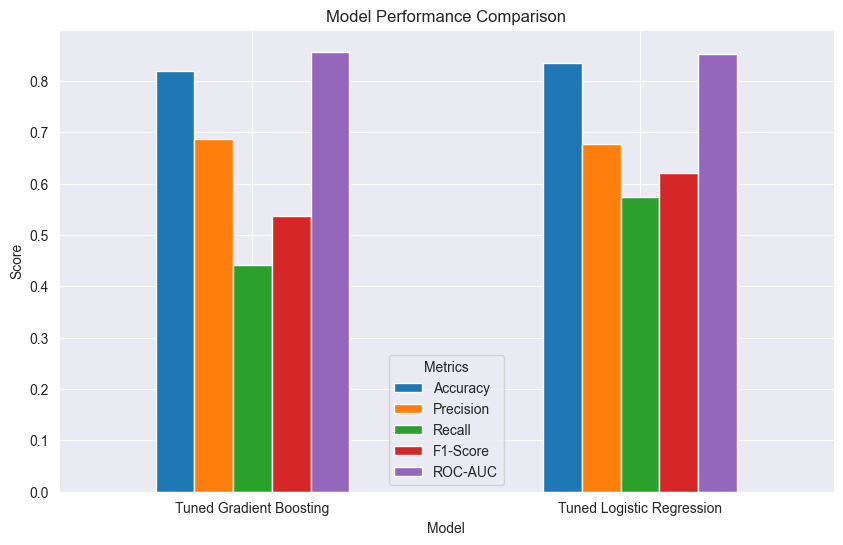

In [5]:
# Model Performance Comparison

# Plot evaluation comparison
results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.show()


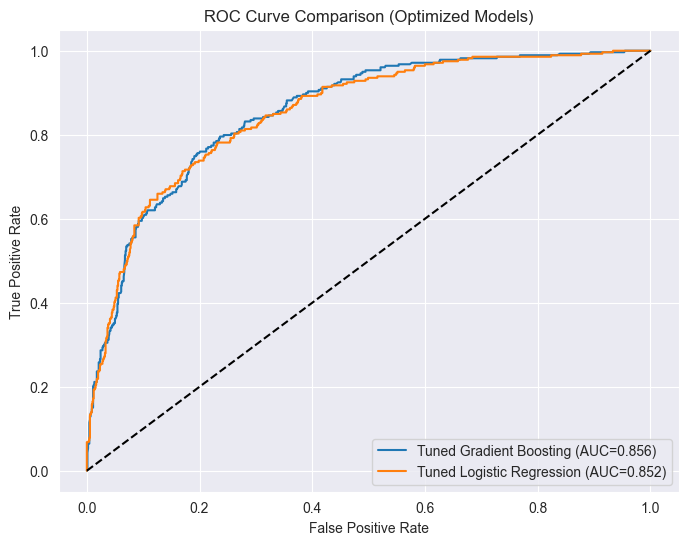

In [6]:
# ROC Curve Comparison (Optimized Models)

plt.figure(figsize=(8,6))

# --- 1. Tuned Gradient Boosting (Top 10 Features) ---
y_prob_gb = best_gb.predict_proba(X_test_top)[:, 1]   # <-- FIXED
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)
plt.plot(fpr_gb, tpr_gb, label=f"Tuned Gradient Boosting (AUC={auc_gb:.3f})")

# --- 2. Tuned Logistic Regression (Full Features) ---
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Tuned Logistic Regression (AUC={auc_lr:.3f})")

# Plot baseline diagonal
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Optimized Models)")
plt.legend()
plt.show()


NameError: name 'ConfusionMatrixDisplay' is not defined

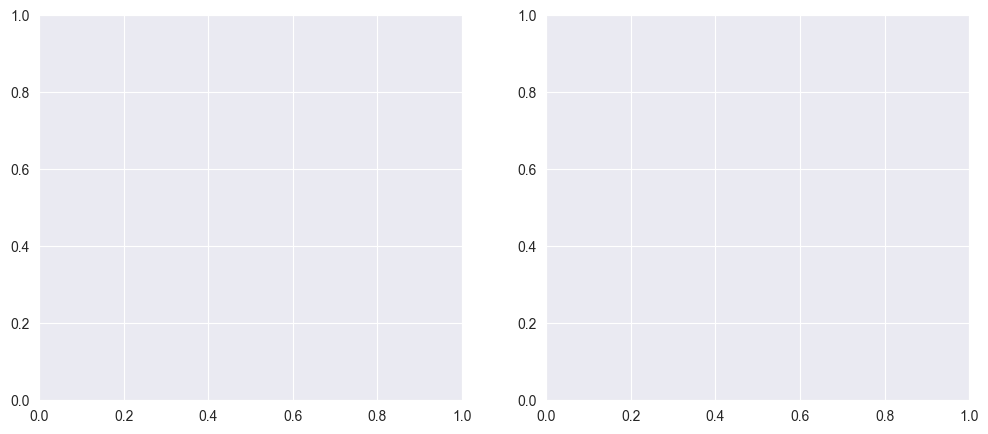

In [7]:
# Tuned Gradient Boosting (Top 10 Features and Tuned Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(12, 5))   # 1 row, 2 columns

models_plot = [
    ("Tuned Gradient Boosting (Top 10 Features)", best_gb, X_test_top),
    ("Tuned Logistic Regression", best_lr, X_test)
]

for ax, (name, model, X_data) in zip(axes, models_plot):
    y_pred = model.predict(X_data)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [ ]:
# Feature importance Plot (Top 10 from GB)

plt.figure(figsize=(10,6))
plt.barh(top_10_features, importances[top_10_indices])
plt.title("Top 10 Feature Importance - Gradient Boosting")
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.show()


In [ ]:
# Compare Full Model vs Top-10 Feature Model

reduced_df = pd.DataFrame([reduced_metrics]).set_index("Model")
combined = pd.concat([results_df, reduced_df])

combined.plot(kind='bar', figsize=(10,6))
plt.title("Full Models vs Top 10 Feature Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(title="Metrics")
plt.show()


# Phase 5: Insights, Visualization & Final Report – Specification

In [ ]:
# Ensure churn column is correctly encoded
if df['churn'].dtype == 'object':
    df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

# Separate features and target
X = df.drop(columns=['churn'])
y = df['churn']

### Feature Importance – Using BEST GRADIENT BOOSTING MODEL

In [ ]:
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_gb.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importances.head(15).plot(
    kind="barh", x="Feature", y="Importance", figsize=(8,6), color="steelblue"
)
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features – Gradient Boosting")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


### ROC Curve – Using the Updated Dataset

In [ ]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": best_gb
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0,1], [0,1], "--", color="gray")
plt.title("ROC Curves – Updated Dataset")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


### Confusion Matrices (Two Models in One Row) – Updated Inputs

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

cm_inputs = {
    "Gradient Boosting (Tuned)": (best_gb, X_test),
    "Logistic Regression": (lr, X_test)
}

i = 1
for name, (model, X_data) in cm_inputs.items():
    y_pred = model.predict(X_data)
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(1, 2, i)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
    plt.title(f"Confusion Matrix – {name}")
    i += 1

plt.tight_layout()
plt.show()


### Churn Distribution

In [ ]:
import seaborn as sns

sns.countplot(x=df['churn'], palette="Blues")
plt.title("Churn Distribution – Clean Stage 2 Dataset")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


### Churn by Tenure Band

In [ ]:
df['tenure_band'] = pd.cut(
    df['tenure'],
    bins=[0,6,12,24,36,48,60,72, df['tenure'].max()],
    labels=["0-6","6-12","12-24","24-36","36-48","48-60","60-72","72+"]
)

tenure_churn = df.groupby("tenure_band")["churn"].mean()

tenure_churn.plot(kind="bar", figsize=(8,5), color="steelblue")
plt.title("Churn Rate by Tenure Band – Clean Stage 2 Dataset")
plt.xlabel("Tenure Band (Months)")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()


### Monthly Charges vs Churn

In [ ]:
sns.boxplot(x=df['churn'], y=df['MonthlyCharges'], palette="Blues")
plt.title("Monthly Charges vs Churn – Clean Stage 2 Dataset")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()


### Power BI Dashboard Mapping (Updated to Your Dataset Columns)

#### Dashboard Areas:

### Page 1 – Executive Overview

- ##### KPI Cards:
    - Overall Churn Rate
    - Model Accuracy
    - ROC–AUC
    - High-Risk Customer Count

- Donut Chart: "churn"

- Bar Chart: "tenure_band" vs churn

- Line Chart: churn over "MonthlyCharges" or "ServiceUsage" (if available)

### Page 2 – Customer Segmentation
 - Churn by:
    - Contract type
    - Payment method
    - Internet services
 - Heatmap: Tenure vs Charges vs Churn

### Page 3 – Driver Analysis
- Feature importance visual (imported as an image)
- Complaints vs Churn (if complaint logs exist)
- Billing Issues vs Churn